In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import pandas as pd

In [30]:
#mortacci nostra è tutto al contrario, Y(Latitudine), X(Longitudine)
def convert_to_modulo(y, x, modulo=5.625):
    x_mod = round(x % modulo, 3)
    y_mod = round(y % -modulo, 3)
    return y_mod, x_mod

# Esempio di utilizzo
y, x = 39.829,-179.52
mod_coords = convert_to_modulo(y, x)
print(mod_coords)  # Output atteso: (modulo 5.625 per x e y, approssimato alla terza cifra decimale)


(-5.171, 0.48)


In [31]:
#in input va y,x, in output escono x,y perchè si passa da coordinate geografiche a pixel

def coord_to_pixel(y,x):
    # Coordinate degli estremi
    x_min, x_max = 0, 5.625
    y_min, y_max = 0, -5.625
    
    # Dimensioni dell'immagine
    width, height = 512, 512
    
    # Conversione delle coordinate x
    pixel_x = int((x - x_min) / (x_max - x_min) * (width - 1))
    
    # Conversione delle coordinate y (l'asse y dell'immagine è invertito)
    pixel_y = int((y - y_min) / (y_max - y_min) * (height - 1))
    
    return pixel_x, pixel_y

# Esempio di utilizzo


y, x = -5.171, 0.48

pixel = coord_to_pixel(y, x)
print(pixel)  # Output atteso: (256, 256)


(43, 469)


43 41
287, 42

In [16]:
def visualize_pixels_matplotlib(image_path, pixels):
    # Carica l'immagine
    img = Image.open(image_path)
    
    # Crea una figura e un set di assi
    fig, ax = plt.subplots()
    
    # Mostra l'immagine
    ax.imshow(img)
    
    # Colore del punto (rosso)
    point_color = 'red'
    
    # Dimensione del punto da disegnare
    point_size = 10
    
    # Aggiungi un cerchio per ogni pixel nella lista
    for (pixel_x, pixel_y) in pixels:
        circle = patches.Circle((pixel_x, pixel_y), point_size, edgecolor=point_color, facecolor='none', linewidth=2)
        ax.add_patch(circle)
    
    # Mostra l'immagine con i pixel evidenziati
    plt.show()


In [51]:
def aggiungi_colonne_pixel(csv_path):
    # Leggi il CSV
    df = pd.read_csv(csv_path)

    # Inizializza le nuove colonne
    pixel_x = []
    pixel_y = []

    # Itera su ogni riga del DataFrame
    for index, row in df.iterrows():
       # print(row['lat'], row['lon'])
        y = row['lat']
        x = row['lon']
       # print(y,x)
        coo_y, coo_x = convert_to_modulo(y, x)
       # print(coo_x, coo_y)
        px, py = coord_to_pixel(coo_y, coo_x)
        pixel_x.append(px)
        pixel_y.append(py)

    # Aggiungi le nuove colonne al DataFrame
    df['pixel_x'] = pixel_x
    df['pixel_y'] = pixel_y
    
    df.to_csv(csv_path, index=False)

    return df

In [52]:
for i in range(16):
    for j in range(64):
        csv_name=f'csv_sam/crateri_{i}_{j}.csv'
        aggiungi_colonne_pixel(csv_name)
        print(f'fatto {i}_{j}')

fatto 0_0
fatto 0_1
fatto 0_2
fatto 0_3
fatto 0_4
fatto 0_5
fatto 0_6
fatto 0_7
fatto 0_8
fatto 0_9
fatto 0_10
fatto 0_11
fatto 0_12
fatto 0_13
fatto 0_14
fatto 0_15
fatto 0_16
fatto 0_17
fatto 0_18
fatto 0_19
fatto 0_20
fatto 0_21
fatto 0_22
fatto 0_23
fatto 0_24
fatto 0_25
fatto 0_26
fatto 0_27
fatto 0_28
fatto 0_29
fatto 0_30
fatto 0_31
fatto 0_32
fatto 0_33
fatto 0_34
fatto 0_35
fatto 0_36
fatto 0_37
fatto 0_38
fatto 0_39
fatto 0_40
fatto 0_41
fatto 0_42
fatto 0_43
fatto 0_44
fatto 0_45
fatto 0_46
fatto 0_47
fatto 0_48
fatto 0_49
fatto 0_50
fatto 0_51
fatto 0_52
fatto 0_53
fatto 0_54
fatto 0_55
fatto 0_56
fatto 0_57
fatto 0_58
fatto 0_59
fatto 0_60
fatto 0_61
fatto 0_62
fatto 0_63
fatto 1_0
fatto 1_1
fatto 1_2
fatto 1_3
fatto 1_4
fatto 1_5
fatto 1_6
fatto 1_7
fatto 1_8
fatto 1_9
fatto 1_10
fatto 1_11
fatto 1_12
fatto 1_13
fatto 1_14
fatto 1_15
fatto 1_16
fatto 1_17
fatto 1_18
fatto 1_19
fatto 1_20
fatto 1_21
fatto 1_22
fatto 1_23
fatto 1_24
fatto 1_25
fatto 1_26
fatto 1_27
fatto 1_

In [56]:
def leggi_coordinate_csv(file_path):
    # Leggi il file CSV
    df = pd.read_csv(file_path)
    
    # Estrai le colonne 'pixel_x' e 'pixel_y' e convertili in una lista di tuple
    coppie = list(zip(df['pixel_x'], df['pixel_y']))
    
    return coppie

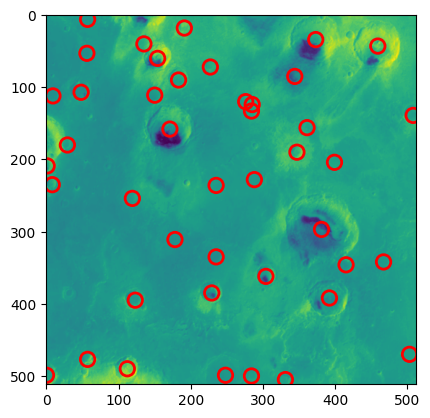

In [57]:
image= 'immagini_sam/immagine_6_30.png'
pixels = leggi_coordinate_csv('csv_sam/crateri_6_30.csv')
visualize_pixels_matplotlib(image, pixels)